## Analyze CDRs

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


We want to create a DataFrame with columns

- chain_type: 'heavy' or 'light'
- ab_resnum
- ab_icode
- total_counts: how often does this residue occur in data set
- contact_counts: how often does this residue make contact to antigen in data set

In [17]:
acp = pd.read_csv("../generated/contacts/atomic_contacts.tsv", sep="\t")
res = pd.read_csv("../generated/contacts/residues.tsv", sep="\t")

In [18]:
acp.head()

,pdb_id,chain_type,ab_chain,ag_chain,ab_resnum,ab_icode,ab_resname,ab_atom,ag_resnum,ag_icode,ag_resname,ag_atom
0,8veb,heavy,G,E,31.0,A,GLY,CA,1018.0,,MET,O
1,8veb,heavy,G,E,31.0,A,GLY,CA,1019.0,,ASP,OD1
2,8veb,heavy,G,E,31.0,A,GLY,C,1018.0,,MET,O
3,8veb,heavy,G,E,31.0,B,GLY,N,1018.0,,MET,O
4,8veb,heavy,G,E,31.0,B,GLY,N,1019.0,,ASP,OD1


In [19]:
res.head()

,pdb_id,chain_type,ab_chain,ab_resnum,ab_icode,ab_resname
0,8veb,heavy,G,1,,GLN
1,8veb,heavy,G,2,,VAL
2,8veb,heavy,G,3,,GLN
3,8veb,heavy,G,4,,LEU
4,8veb,heavy,G,5,,LEU


We can compute the number of residue contacts using grouping of the `acp` DataFrame.

We check per pdb_id and ab_resnum how many lines we have (here we count ag_resnum, but we could count any column). This is the number of atom contacts, as every line corresponds to an atom contact.

We also check how many unique ag_resnums we have. That is the number of contacts between different ag_resnums.

The grouping we have to use is (pdb_id, ab_resnum, ab_icode), 
The colums ab_chain, chain_type, and ab_resname are only for annotation purposes.

In [20]:
rcp = (acp
       .groupby(['pdb_id', 'ab_chain','chain_type', 'ab_resnum', 'ab_icode', 'ab_resname'])
       .agg(natomcontacts = ('ag_resnum', 'size'),
            nrescontacts = ('ag_resnum', 'nunique')).reset_index())

rcp["contact"] = rcp["natomcontacts"] > 0   # always > 0, as we only have rows with atom contacts in acp

rcp.head()

,pdb_id,ab_chain,chain_type,ab_resnum,ab_icode,ab_resname,natomcontacts,nrescontacts,contact
0,1adq,H,heavy,1.0,,GLU,10,3,True
1,1adq,H,heavy,31.0,,ASP,17,3,True
2,1adq,H,heavy,52.0,A,TRP,11,2,True
3,1adq,H,heavy,96.0,,ARG,5,2,True
4,1adq,H,heavy,97.0,,SER,3,1,True


The data frame rcp now tells us if a (pdb_id, ab_chain, ab_resnum, ab_icode) has a contact to any antigen residue.

Now we want to look at how frequent  a given heavy chain (or light chain) residue has contact to a antigen residue.

So we need to get the total number of antibody residues (which could have a contact). We get this from the res data frame.


In [21]:
m = (res
     .merge(rcp, how = "left", 
            on = ["pdb_id", "chain_type", "ab_chain", "ab_resnum", "ab_icode", "ab_resname"])
     .fillna(0))

m.head()





,pdb_id,chain_type,ab_chain,ab_resnum,ab_icode,ab_resname,natomcontacts,nrescontacts,contact
0,8veb,heavy,G,1,,GLN,0.0,0.0,0
1,8veb,heavy,G,2,,VAL,0.0,0.0,0
2,8veb,heavy,G,3,,GLN,0.0,0.0,0
3,8veb,heavy,G,4,,LEU,0.0,0.0,0
4,8veb,heavy,G,5,,LEU,0.0,0.0,0


In [22]:
m.to_csv("../generated/contacts/residue_contacts_all.tsv", sep= "\t", index=False)

Now we can create a data frame where for every
- chain_type
- resnum
- icode

we compute 
- the total number of occurrences
- the total number of contacts

In [23]:
stats = (m
         .groupby(["chain_type", "ab_resnum", "ab_icode"])
         .agg(nresidues = ("ab_resname", "size"),
              ncontacts = ("contact", "sum"))
         .reset_index())

stats = stats.assign(ab_res = stats["ab_resnum"].astype(str) + stats["ab_icode"])

stats.head()
    

,chain_type,ab_resnum,ab_icode,nresidues,ncontacts,ab_res
0,heavy,1,,753,44,1
1,heavy,2,,938,110,2
2,heavy,3,,951,2,3
3,heavy,4,,954,1,4
4,heavy,5,,954,0,5


In [24]:
sm = stats.melt(id_vars = ["chain_type", "ab_resnum", "ab_icode", "ab_res"], 
           var_name = "stat", value_name = "count")

sm.head()

,chain_type,ab_resnum,ab_icode,ab_res,stat,count
0,heavy,1,,1,nresidues,753
1,heavy,2,,2,nresidues,938
2,heavy,3,,3,nresidues,951
3,heavy,4,,4,nresidues,954
4,heavy,5,,5,nresidues,954


Now we can look at the CDR regions

In [25]:
import seaborn as sns

<Axes: xlabel='ab_res', ylabel='nresidues'>

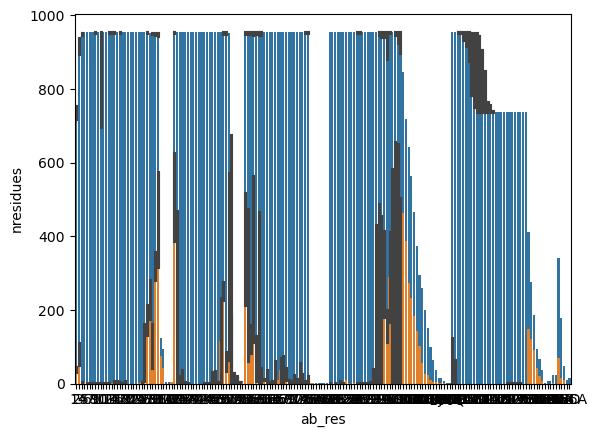

In [26]:
sns.barplot(data=stats, x="ab_res", y="nresidues")
sns.barplot(data=stats, x="ab_res", y="ncontacts")

<Axes: xlabel='ab_res', ylabel='count'>

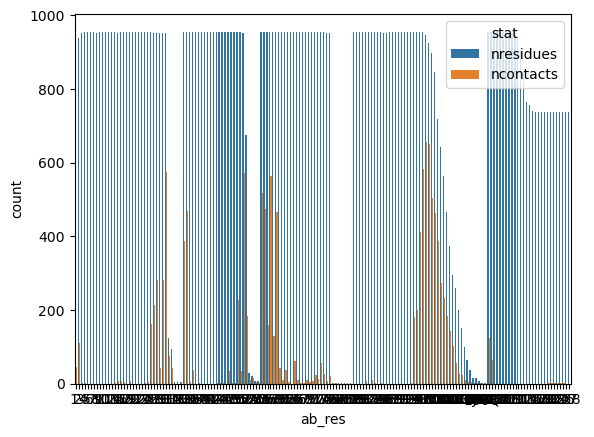

In [27]:
sns.barplot(data = sm.query("chain_type == 'heavy'"), 
            x = "ab_res", y = "count", hue = "stat")

<Axes: xlabel='ab_res', ylabel='count'>

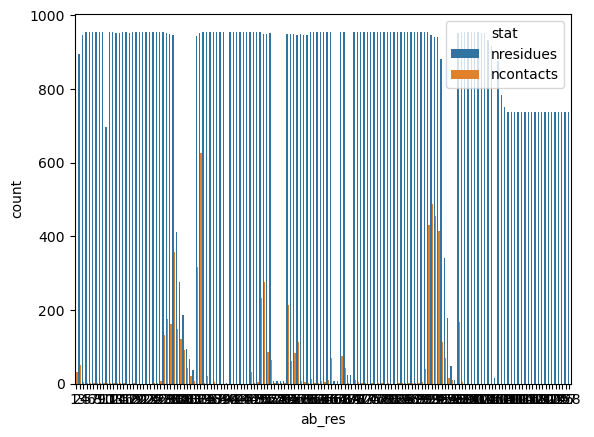

In [28]:
sns.barplot(data = sm.query("chain_type == 'light'"), 
            x = "ab_res", y = "count", hue = "stat")

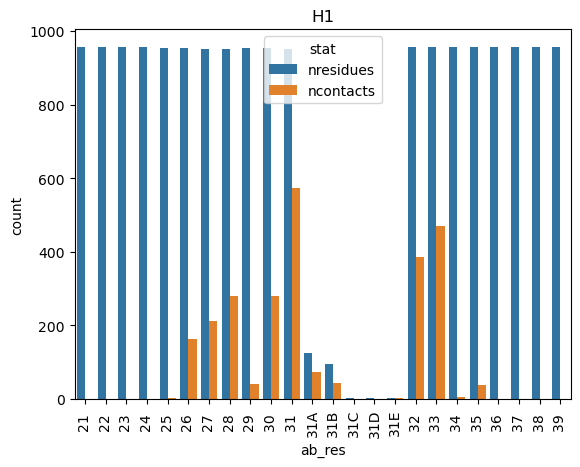

In [29]:
(sns
 .barplot(data = sm.query("chain_type == 'heavy' and 20 < ab_resnum < 40"), 
            x = "ab_res", y = "count", hue = "stat"))
plt.title ("H1")
plt.xticks(rotation=90)

#plt.tight_layout()
plt.show()


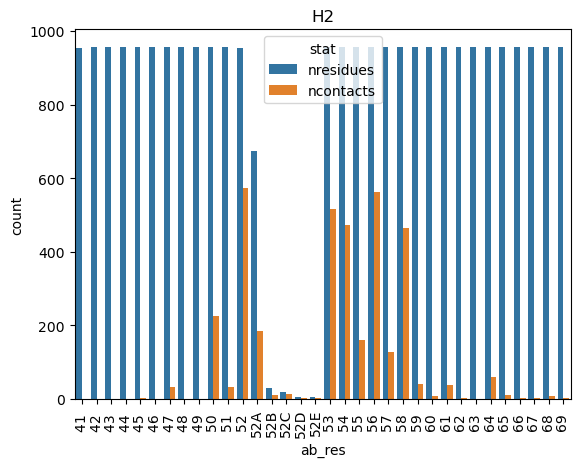

In [30]:
sns.barplot(data = sm.query("chain_type == 'heavy' and 40 < ab_resnum < 70"), 
            x = "ab_res", y = "count", hue = "stat")
plt.xticks(rotation=90)
plt.title("H2")
#plt.tight_layout()
plt.show()


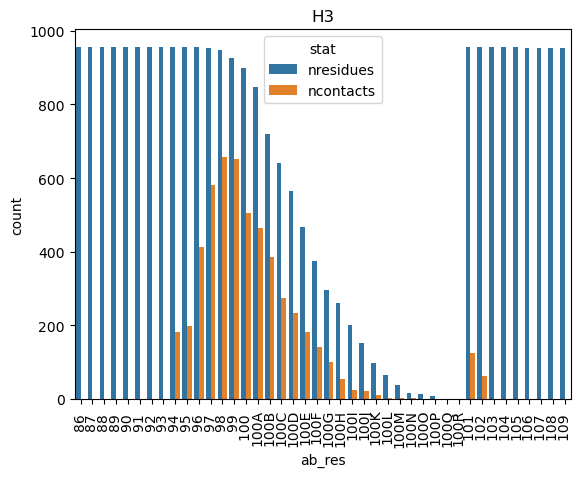

In [31]:
sns.barplot(data = sm.query("chain_type == 'heavy' and 85 < ab_resnum < 110"), 
            x = "ab_res", y = "count", hue = "stat")
plt.xticks(rotation=90)
plt.title("H3")
#plt.tight_layout()
plt.show()
